# Chapter 10: Clustering Techniques

## 📋 Summary

Clustering is **unsupervised learning** — finding natural groupings in data without labels. It is widely used for customer segmentation, anomaly detection, document grouping, and exploratory data analysis. This chapter covers K-Means, hierarchical clustering, DBSCAN, Gaussian Mixture Models, and cluster evaluation metrics.

---

## 🧠 Theoretical Explanation

### K-Means Clustering
K-Means partitions data into K clusters by minimizing **within-cluster sum of squares (WCSS)**:

`WCSS = Σk Σi∈Ck ||xi - μk||²`

**Algorithm (Lloyd's algorithm)**:
1. Initialize K centroids randomly
2. Assign each point to the nearest centroid
3. Recompute centroids as mean of assigned points
4. Repeat until convergence

Choosing K: **Elbow method** plots WCSS vs K — look for the elbow. **Silhouette score** measures how similar a point is to its own cluster vs other clusters (range: -1 to 1).

### Hierarchical Clustering
Builds a tree (dendrogram) of nested clusters:
- **Agglomerative** (bottom-up): Start with each point as its own cluster, merge closest pairs
- **Divisive** (top-down): Start with all points in one cluster, split recursively

Linkage criteria determine how distance between clusters is measured: single, complete, average, Ward.

### DBSCAN (Density-Based Spatial Clustering)
Groups points that are closely packed and marks outliers in low-density regions:
- **Core point**: Has ≥ `min_samples` points within radius `eps`
- **Border point**: Within eps of a core point but fewer than min_samples neighbors
- **Noise point**: Neither core nor border — labeled as -1 (outlier)

Advantages: Finds arbitrary shapes, automatically detects outliers, no need to specify K.

### Cluster Evaluation
Without ground truth:
- **Silhouette score**: `(b-a)/max(a,b)` where a=intra-cluster distance, b=nearest-cluster distance. Higher is better.
- **Davies-Bouldin index**: Ratio of within-cluster scatter to between-cluster separation. Lower is better.

With ground truth:
- **Adjusted Rand Index (ARI)**: Similarity between two clusterings, adjusted for chance
- **Normalized Mutual Information (NMI)**


## 10.1 K-Means Clustering

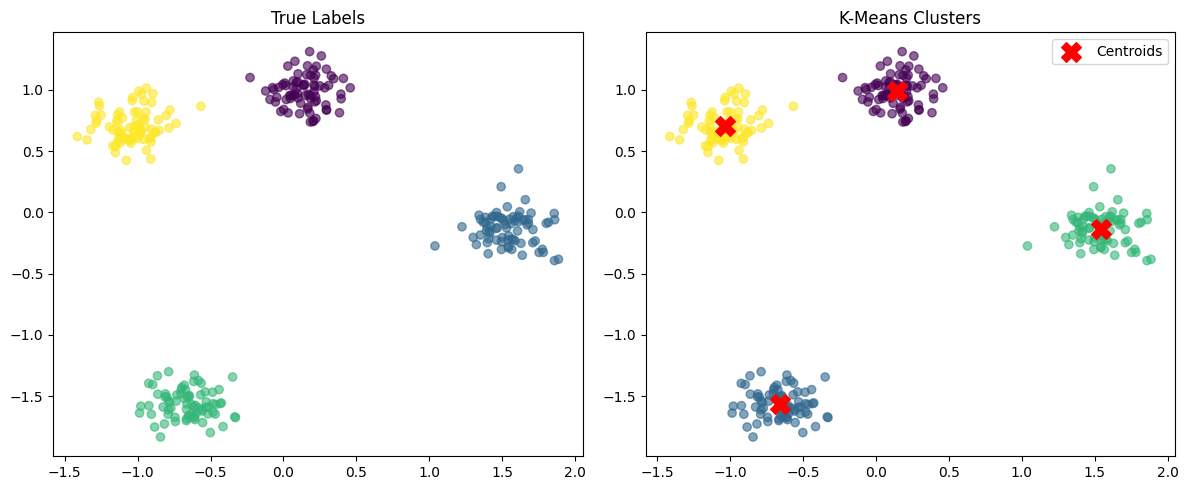

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Generate sample data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6)
plt.title('True Labels')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clusters')
plt.legend()
plt.tight_layout(); plt.show()

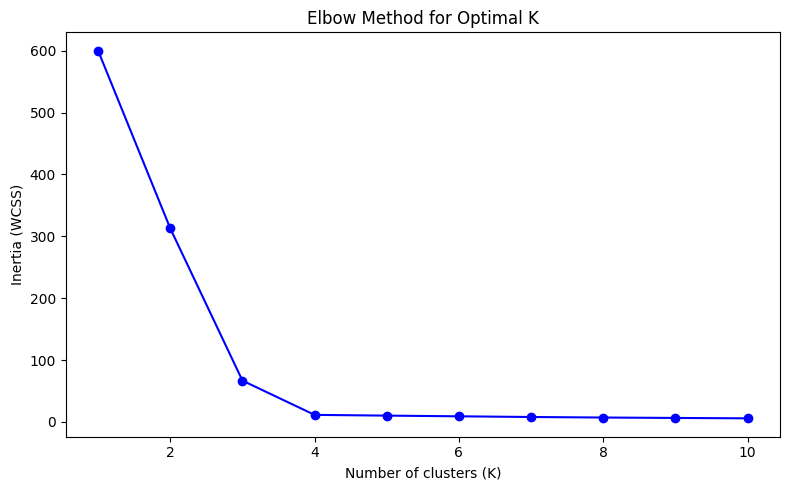

In [2]:
# Elbow method to choose K
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.tight_layout(); plt.show()

## 10.2 Cluster Evaluation Metrics

In [3]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ari = adjusted_rand_score(y_true, labels)
    print(f'K={k}: Silhouette={sil:.3f}, Davies-Bouldin={db:.3f}, ARI={ari:.3f}')

K=2: Silhouette=0.570, Davies-Bouldin=0.555, ARI=0.331
K=3: Silhouette=0.764, Davies-Bouldin=0.349, ARI=0.712
K=4: Silhouette=0.839, Davies-Bouldin=0.224, ARI=1.000
K=5: Silhouette=0.708, Davies-Bouldin=0.553, ARI=0.915
K=6: Silhouette=0.577, Davies-Bouldin=0.799, ARI=0.828
K=7: Silhouette=0.456, Davies-Bouldin=0.966, ARI=0.723


## 10.3 Hierarchical Clustering

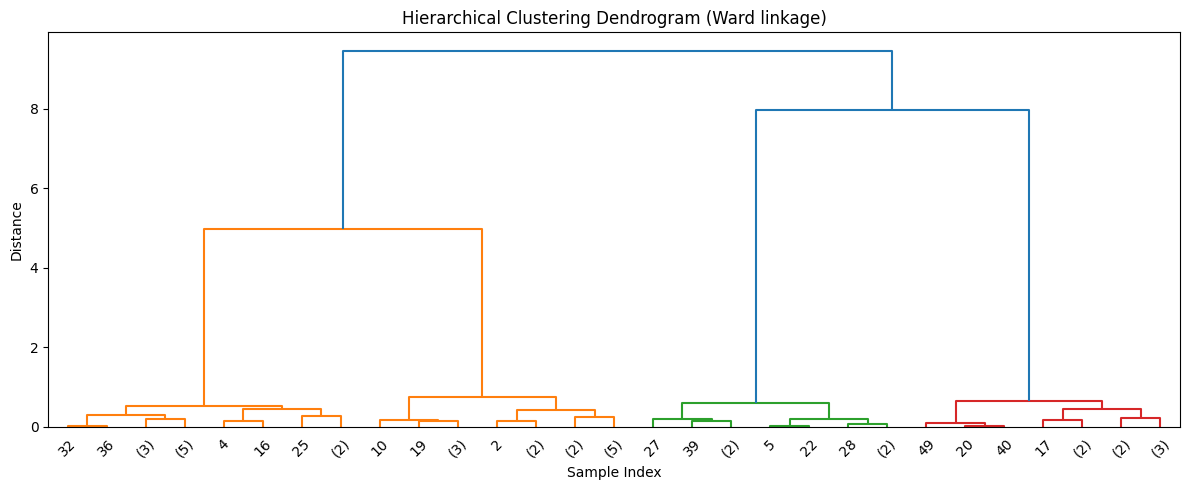

Agglomerative ARI: 1.0000


In [4]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogram (on small subset for clarity)
X_small = X[:50]
Z = linkage(X_small, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=4)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('Sample Index'); plt.ylabel('Distance')
plt.tight_layout(); plt.show()

# Fit AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg.fit_predict(X)
print(f'Agglomerative ARI: {adjusted_rand_score(y_true, agg_labels):.4f}')

## 10.4 DBSCAN — Density-Based Clustering

DBSCAN found 2 clusters and 0 noise points


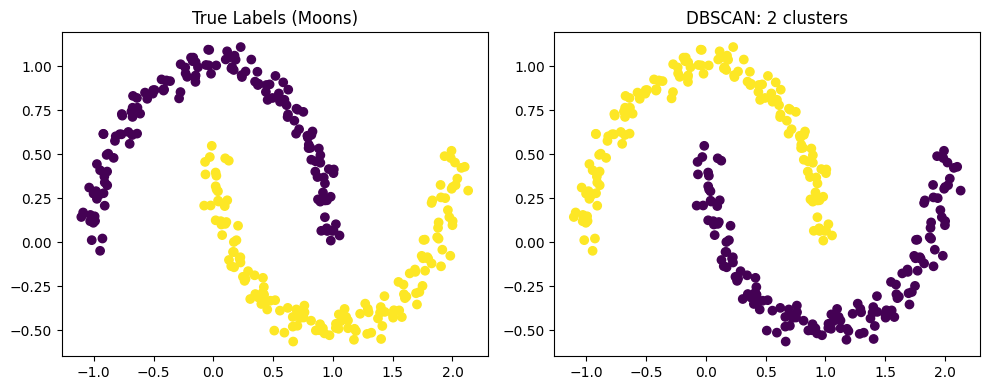

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# DBSCAN excels at non-spherical shapes
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X_moons)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f'DBSCAN found {n_clusters} clusters and {n_noise} noise points')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis')
plt.title('True Labels (Moons)')

plt.subplot(1, 2, 2)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=db_labels, cmap='viridis')
plt.title(f'DBSCAN: {n_clusters} clusters')
plt.tight_layout(); plt.show()

## 🔑 Key Takeaways

- **K-Means** is fast and scalable but assumes spherical clusters and requires K upfront. Use the elbow method or silhouette score to choose K.
- **Hierarchical clustering** builds a dendrogram — useful when you want to explore different K values without retraining.
- **DBSCAN** handles arbitrary shapes and automatically identifies outliers — but requires careful eps/min_samples tuning.
- **Silhouette score** measures cluster quality without ground truth: values close to 1 are ideal.
- Always **scale features** before clustering — distance metrics are scale-sensitive.
- Consider reducing dimensions with PCA before clustering high-dimensional data.
